# 04b · Theme 2: Commerce Orientation

Explicit caption commerce cues: intensity, where cues cluster, Nike vs Adidas, and association with engagement (BRI).

**Sample.** 4,457 search-visible Nike and Adidas videos. Measures caption cues, not sales or conversion. Descriptive only.

**Sections**
1. Commerce Intensity
2. Intensity by content and product
3. Nike vs Adidas
4. Intensity and engagement
5. Intensity × BRI matrix
6. Summary

Locked takeaways: [`05_summary.ipynb`](./05_summary.ipynb) (Theme 2).


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
def _show_fig(fig):
    """Show figure in Cursor/VS Code notebooks without end-of-cell double flush."""
    import io
    from IPython.display import Image, display
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    display(Image(buf.getvalue()))

from tiktok_brand.analysis.data import CLUSTER_COL, load_feature_table, project_paths
from tiktok_brand.analysis.commerce import (
    CONTENT_DIMS,
    PRODUCT_DIMS,
    add_commerce_intensity,
    brand_commerce_summary,
    brand_dim_commerce_wide,
    commerce_by_dimension,
    commerce_engagement_bubbles,
    commerce_engagement_trend,
)
from tiktok_brand.analysis.plots import (
    brand_commerce_rate_bars,
    brand_dim_commerce_hbar,
    commerce_bri_bubbles,
    commerce_engagement_line,
    commerce_intensity_hbar,
)
from tiktok_brand.analysis.present import format_cluster_label, humanize_label

import os
os.chdir(ROOT)
PATHS = project_paths(ROOT / "configs" / "project.yaml")
df = load_feature_table(PATHS["feature_table"])
df["content_cluster"] = df[CLUSTER_COL].map(format_cluster_label)
df = add_commerce_intensity(df)

print(
    f"rows={len(df):,}  "
    f"mean_score={df['commerce_intensity_score'].mean():.2f}  "
    f"has_giveaway_rate={df['has_giveaway'].mean():.1%}"
)


rows=4,457  mean_score=0.04  has_giveaway_rate=0.1%


## 1. Commerce Intensity

Score = Purchase CTA + Discovery CTA + Promo language + Giveaway (0–4).

| Score | Bin |
|------:|:----|
| 0 | None |
| 1 | Low |
| 2 | Medium |
| ≥ 3 | High |


In [2]:
comp = df[["has_purchase_cta", "has_discovery_traffic_cta", "has_promo_language", "has_giveaway"]].mean()
comp.index = ["purchase_cta", "discovery_cta", "promo_language", "giveaway"]
display(comp.rename("rate").to_frame().style.format("{:.1%}"))

mix = (
    df["commerce_intensity"]
    .astype(str)
    .value_counts()
    .reindex(["None", "Low", "Medium", "High"])
    .to_frame("n")
)
mix["share"] = mix["n"] / mix["n"].sum()
display(mix.style.format({"share": "{:.1%}"}))

,rate
purchase_cta,0.8%
discovery_cta,0.9%
promo_language,1.8%
giveaway,0.1%


,n,share
commerce_intensity,,
None,4299.000000,96.5%
Low,154.000000,3.5%
Medium,4.000000,0.1%
High,nan,nan%


## 2. Intensity by content and product

Parallel cross-tabs on content type, cluster, brand style, visual presentation, and product taxonomy.



=== Content type (n levels=7) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Product Promo,123,0.47,0.0%,9.8%,23.6%
1,Collaboration,146,0.07,0.0%,1.4%,4.1%
2,Product Showcase,162,0.05,0.0%,1.9%,1.9%
3,Product Review,109,0.05,0.0%,1.8%,1.8%
4,Vibe OOTD,301,0.03,0.0%,1.7%,1.3%
5,Tutorial Utility,85,0.01,0.0%,0.0%,1.2%
6,Official Campaign,38,0.00,0.0%,0.0%,0.0%


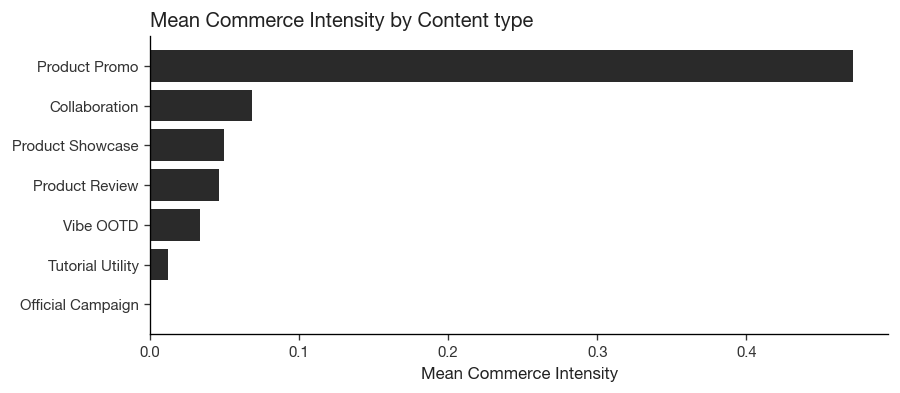


=== Text / content cluster (n levels=13) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,"1 — Jordan Brand Culture, Releases & Community",156,0.13,0.0%,1.3%,8.3%
1,"3 — Interactive Brand, Creator & Pop-Culture Content",450,0.07,0.0%,1.8%,2.9%
2,10 — Nike Air Product Lines & Commerce,210,0.04,0.0%,0.0%,2.9%
3,2 — Sneaker Shopping & Product Discovery,557,0.04,0.0%,1.3%,2.3%
4,"0 — Ootd, Outfit Inspiration & Streetwear",568,0.04,0.0%,1.2%,1.9%
5,"7 — Sneakerhead Reviews, Styling & Enthusiast Culture",399,0.04,0.0%,1.0%,1.5%
6,"6 — Running Shoes, Training & Marathon Culture",354,0.03,0.0%,0.6%,1.4%
7,5 — Elite Athlete Stories & Sporting Moments,414,0.03,0.0%,0.2%,1.4%
8,4 — Basketball Athletes & Signature Footwear,220,0.02,0.0%,0.5%,0.5%
9,9 — Football Athletes & Adidas Football Culture,428,0.01,0.0%,0.2%,1.2%


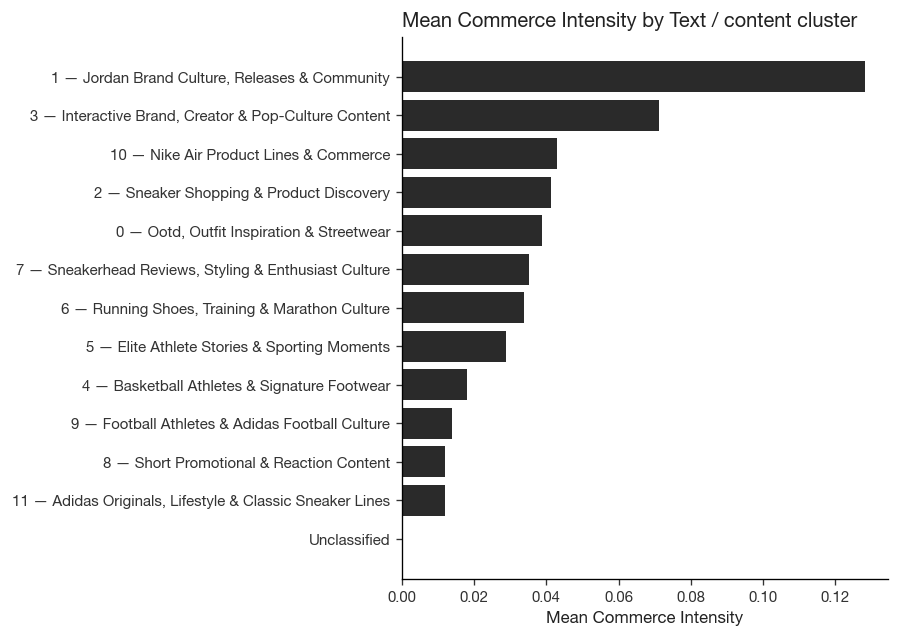


=== Brand style (n levels=4) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Retro,93,0.11,0.0%,2.2%,7.5%
1,Performance,370,0.05,0.0%,0.8%,3.5%
2,Lifestyle,525,0.03,0.0%,1.3%,1.5%
3,Technical,130,0.03,0.0%,1.5%,1.5%


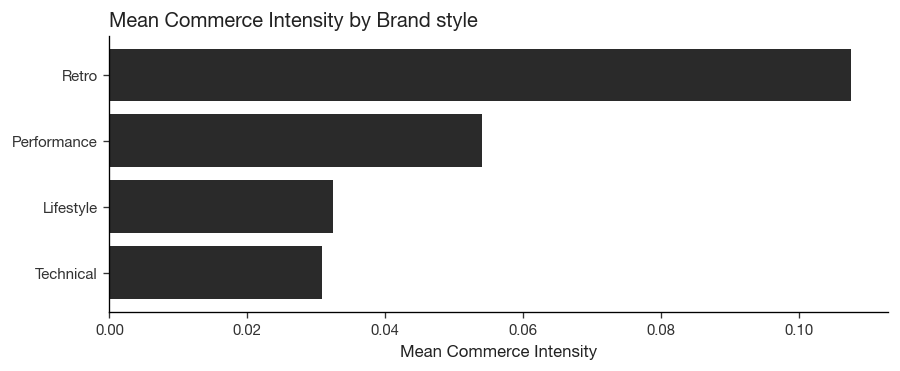


=== Visual format (n levels=7) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Archival Retro,49,0.08,0.0%,2.0%,4.1%
1,Other,89,0.08,0.0%,0.0%,6.7%
2,Talking Head,449,0.04,0.0%,0.7%,2.4%
3,Product Closeup,1381,0.04,0.0%,0.7%,1.9%
4,Unclassified,693,0.03,0.0%,1.0%,2.2%
5,Sports Action,567,0.03,0.0%,0.5%,1.6%
6,On Body Styling,1215,0.03,0.0%,0.8%,1.0%


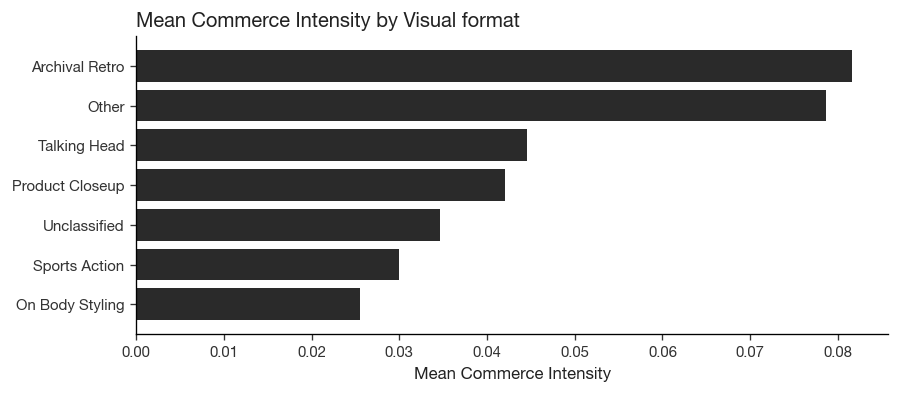


=== Visual setting (n levels=9) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Gym Training,313,0.05,0.0%,0.6%,3.2%
1,Event Crowd,277,0.05,0.0%,1.1%,2.2%
2,Other,152,0.04,0.0%,0.7%,2.0%
3,Outdoor,785,0.04,0.0%,0.6%,2.2%
4,Retail Store,1273,0.04,0.0%,0.9%,1.7%
5,Unclassified,693,0.03,0.0%,1.0%,2.2%
6,Sports Venue,383,0.03,0.0%,0.5%,0.3%
7,Studio,525,0.03,0.0%,0.6%,1.5%
8,Home Indoor,56,0.00,0.0%,0.0%,0.0%


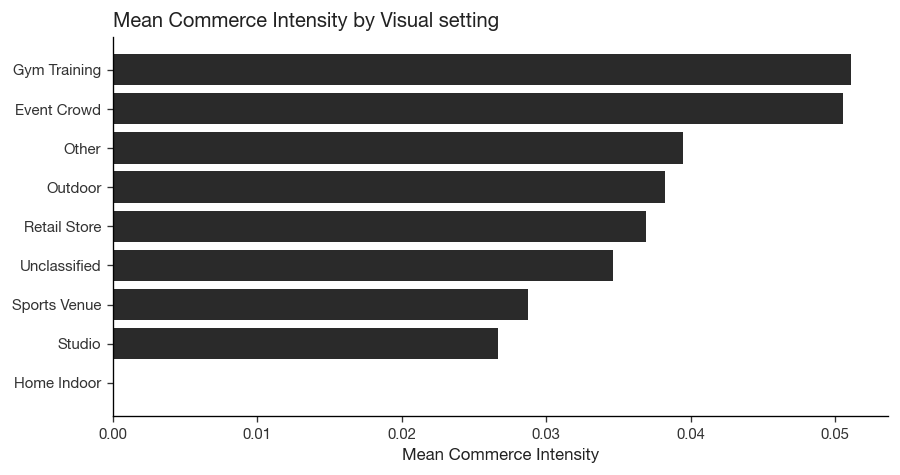


=== Product category (n levels=4) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Accessories,333,0.05,0.0%,0.9%,2.4%
1,Shoes,2013,0.04,0.0%,0.6%,2.3%
2,Apparel,431,0.04,0.0%,1.9%,0.9%
3,Uncategorized,1819,0.03,0.0%,0.7%,1.5%


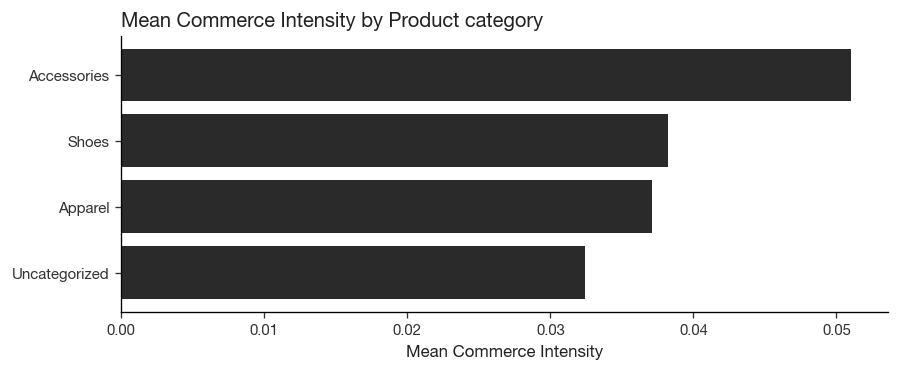


=== Product line (n levels=16) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Jordan,158,0.11,0.0%,1.3%,6.3%
1,Tracksuit,62,0.08,0.0%,3.2%,3.2%
2,Air Max,96,0.06,0.0%,1.0%,5.2%
3,Superstar,24,0.04,0.0%,4.2%,0.0%
4,Af1,73,0.04,0.0%,0.0%,2.7%
5,Samba,222,0.03,0.0%,2.3%,0.5%
6,Gazelle,111,0.02,0.0%,0.0%,0.9%
7,Originals Apparel,114,0.02,0.0%,0.9%,0.0%
8,Spezial,121,0.02,0.0%,0.8%,0.8%
9,Tech Fleece,94,0.01,0.0%,1.1%,0.0%


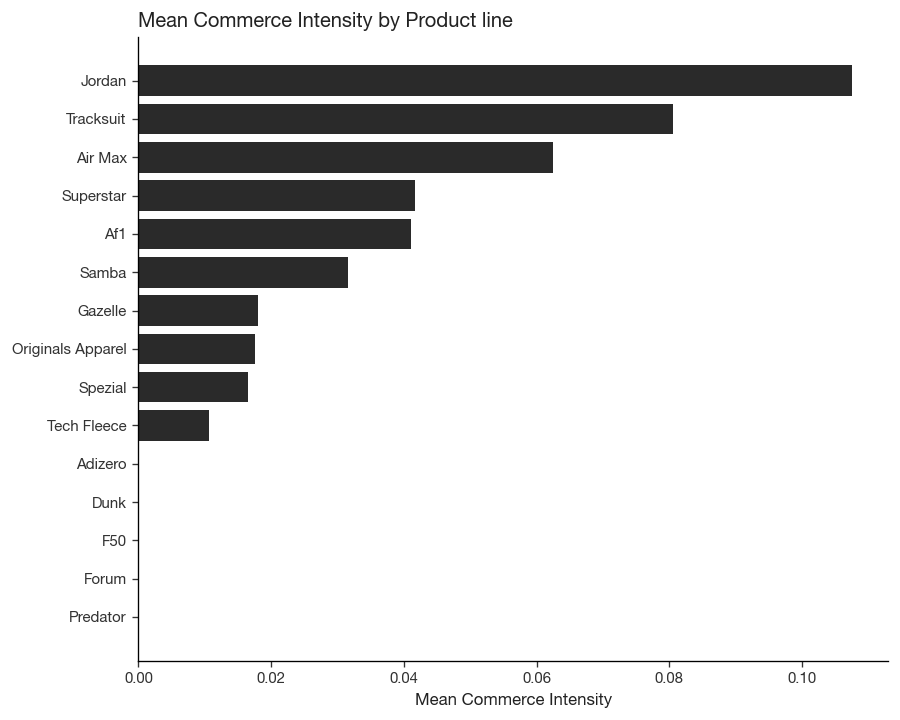

In [3]:
DIM_LABELS = {
    "content_type": "Content type",
    "content_cluster": "Text / content cluster",
    "brand_styles": "Brand style",
    "visual_format": "Visual format",
    "visual_setting": "Visual setting",
    "product_categories": "Product category",
    "product_lines": "Product line",
}

tabs = {}
for dim in list(CONTENT_DIMS) + list(PRODUCT_DIMS):
    if dim not in df.columns:
        print(f"skip missing: {dim}")
        continue
    tab = commerce_by_dimension(df, dim, min_count=15)
    tabs[dim] = tab
    title = DIM_LABELS.get(dim, dim)
    print(f"\n=== {title} (n levels={len(tab)}) ===")
    show = tab[
        [
            "level",
            "n",
            "mean_commerce_intensity",
            "high_commerce_share",
            "purchase_cta_rate",
            "promo_language_rate",
        ]
    ].copy()
    show["level"] = show["level"].map(humanize_label)
    display(
        show.style.format(
            {
                "mean_commerce_intensity": "{:.2f}",
                "high_commerce_share": "{:.1%}",
                "purchase_cta_rate": "{:.1%}",
                "promo_language_rate": "{:.1%}",
            }
        )
    )
    fig = commerce_intensity_hbar(tab, title=f"Mean Commerce Intensity by {title}")
    _show_fig(fig)


## 3. Nike vs Adidas

Compare mean intensity, any-commerce share, component rates, and concentration by content type and product line. Medium/High cells are sparse; brand charts emphasize any cue vs none.


### 3.1 Overall orientation

Component rates (Purchase, Discovery/traffic, Promo; Giveaway ~0.1% omitted from the primary chart) and mean intensity / any-commerce share by brand.


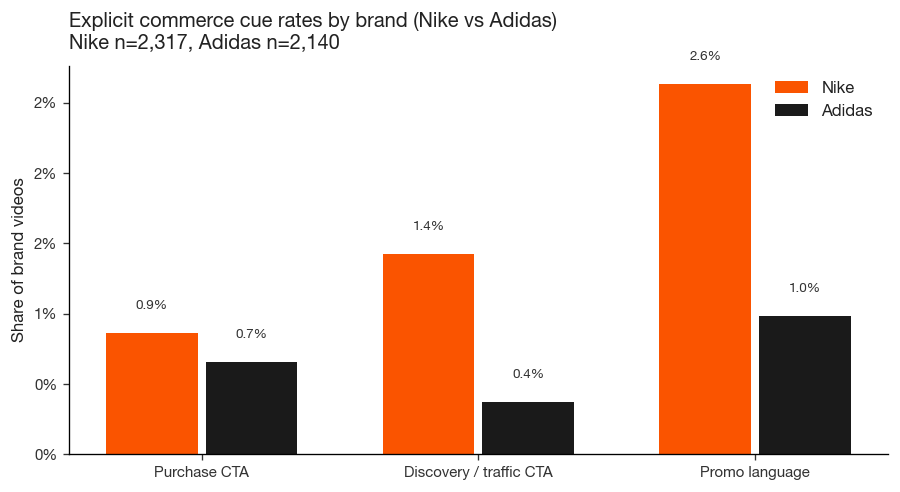

brand,N,Mean Commerce Intensity,Any-Commerce Share
Nike,"2,317",0.050,4.9%
Adidas,"2,140",0.021,2.1%


In [4]:
summary = brand_commerce_summary(df)
_show_fig(
    brand_commerce_rate_bars(
        summary,
        title="Explicit commerce cue rates by brand (Nike vs Adidas)",
    )
)

compact = summary[["brand", "n", "mean_commerce_intensity", "any_commerce_share"]].copy()
compact["brand"] = compact["brand"].str.title()
compact = compact.rename(
    columns={
        "n": "N",
        "mean_commerce_intensity": "Mean Commerce Intensity",
        "any_commerce_share": "Any-Commerce Share",
    }
)
display(
    compact.style.format(
        {
            "Mean Commerce Intensity": "{:.3f}",
            "Any-Commerce Share": "{:.1%}",
            "N": "{:,}",
        }
    ).hide(axis="index")
)

nike = summary.loc[summary["brand"] == "nike"].iloc[0]
adi = summary.loc[summary["brand"] == "adidas"].iloc[0]


### 3.2 Content context

Mean intensity by content type, Nike vs Adidas. Gray / `*`: either brand *n* < 15.


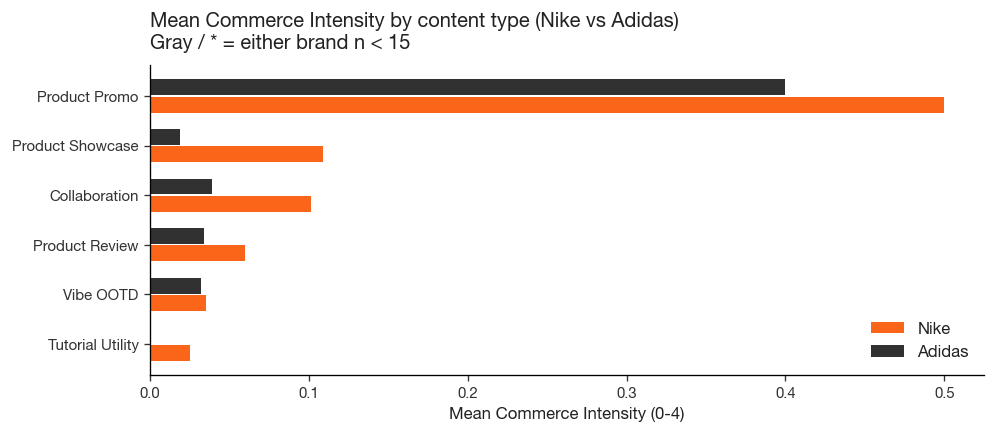

Content type,Nike mean,Adidas mean,Nike − Adidas,Nike n,Adidas n
Product Promo,0.50,0.40,+0.10,88,35
Product Showcase,0.11,0.02,+0.09,55,107
Collaboration,0.10,0.04,+0.06,69,77
Product Review,0.06,0.03,+0.03,50,59
Vibe OOTD,0.04,0.03,+0.00,113,188
Tutorial Utility,0.03,0.00,+0.03,40,45


In [5]:
ct_wide = brand_dim_commerce_wide(
    df, "content_type", min_count=15, min_signal=0.0, require_both_brands=False
)
# Prefer types where at least one brand is adequately sized
ct_plot = ct_wide[
    (ct_wide["n_nike"] >= 15) | (ct_wide["n_adidas"] >= 15)
].sort_values("max_mean", ascending=False)

_show_fig(
    brand_dim_commerce_hbar(
        ct_plot,
        title="Mean Commerce Intensity by content type (Nike vs Adidas)",
        small_n=15,
        top_n=12,
    )
)

# Tiny evidence table for adequately sized types only
ct_tbl = ct_plot[(ct_plot["n_nike"] >= 15) & (ct_plot["n_adidas"] >= 15)].copy()
ct_tbl["Content type"] = ct_tbl["level"].map(humanize_label)
ct_tbl = ct_tbl.rename(
    columns={
        "mean_nike": "Nike mean",
        "mean_adidas": "Adidas mean",
        "n_nike": "Nike n",
        "n_adidas": "Adidas n",
        "gap": "Nike − Adidas",
    }
)[
    ["Content type", "Nike mean", "Adidas mean", "Nike − Adidas", "Nike n", "Adidas n"]
]
display(
    ct_tbl.style.format(
        {
            "Nike mean": "{:.2f}",
            "Adidas mean": "{:.2f}",
            "Nike − Adidas": "{:+.2f}",
            "Nike n": "{:,}",
            "Adidas n": "{:,}",
        }
    ).hide(axis="index")
)


### 3.3 Product lines

Product lines with adequate *n* and a non-zero signal on at least one brand. `*` / n/a: missing or *n* < 20.


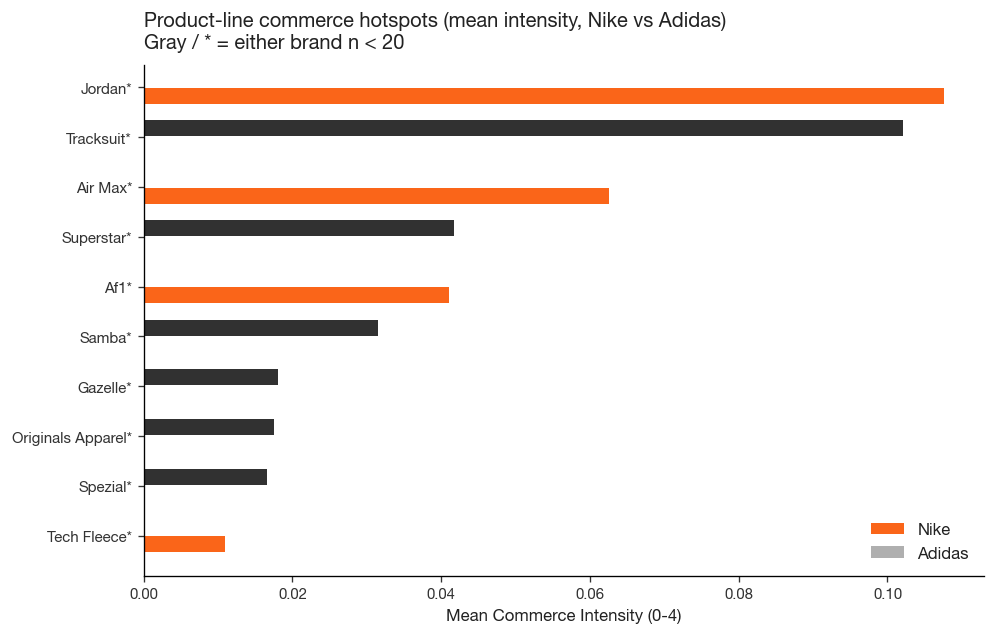

Product line,Nike mean,Adidas mean,Nike n,Adidas n
Jordan*,0.11,n/a,158,n/a
Tracksuit*,0.00,0.10,13,49
Air Max*,0.06,n/a,96,n/a
Superstar*,n/a,0.04,n/a,24
Af1*,0.04,n/a,73,n/a
Samba*,n/a,0.03,n/a,222
Gazelle*,n/a,0.02,n/a,111
Originals Apparel*,n/a,0.02,n/a,114
Spezial*,n/a,0.02,n/a,121
Tech Fleece*,0.01,0.00,92,2


In [6]:
pl_wide = brand_dim_commerce_wide(
    df,
    "product_lines",
    min_count=20,
    min_signal=0.01,
    require_both_brands=False,
)
pl_plot = pl_wide.sort_values("max_mean", ascending=False).head(10)

_show_fig(
    brand_dim_commerce_hbar(
        pl_plot,
        title="Product-line commerce hotspots (mean intensity, Nike vs Adidas)",
        small_n=20,
        top_n=10,
    )
)

pl_tbl = pl_plot.copy()
pl_tbl["Product line"] = pl_tbl["level"].map(humanize_label)
pl_tbl["note"] = pl_tbl.apply(
    lambda r: "*" if (r["n_nike"] < 20 or r["n_adidas"] < 20) else "",
    axis=1,
)
pl_tbl["Product line"] = pl_tbl["Product line"] + pl_tbl["note"]
pl_tbl = pl_tbl.rename(
    columns={
        "mean_nike": "Nike mean",
        "mean_adidas": "Adidas mean",
        "n_nike": "Nike n",
        "n_adidas": "Adidas n",
    }
)[["Product line", "Nike mean", "Adidas mean", "Nike n", "Adidas n"]]
display(
    pl_tbl.style.format(
        {
            "Nike mean": lambda v: "n/a" if v != v else f"{v:.2f}",
            "Adidas mean": lambda v: "n/a" if v != v else f"{v:.2f}",
            "Nike n": lambda v: "n/a" if int(v) == 0 else f"{int(v):,}",
            "Adidas n": lambda v: "n/a" if int(v) == 0 else f"{int(v):,}",
        }
    ).hide(axis="index")
)


### Section 3 note

Explicit commerce is uncommon for both brands. Nike uses these cues more often; the gap is concentrated in promotional, showcase, collaboration, and selected product contexts.


## 4. Intensity and engagement

Association of commerce bins with median BRI, WER, and Top-10% rate (sample WER ≥ Q90). Shape may be monotone, inverted-U, or unclear; no assumed engagement penalty.


Top-10% = WER >= sample Q90 (0.01729)


,commerce_intensity,n,median_bri,median_wer,top10_rate
0,None,4299,1.005,0.0064,10.0%
1,Low,154,0.952,0.0058,11.7%
2,Medium,4,0.870,0.0051,0.0%
3,High,0,nan,nan,nan%


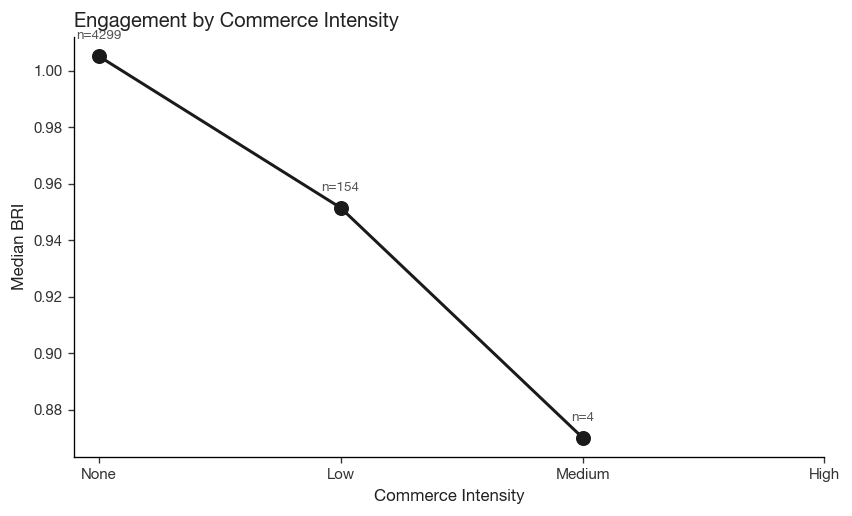

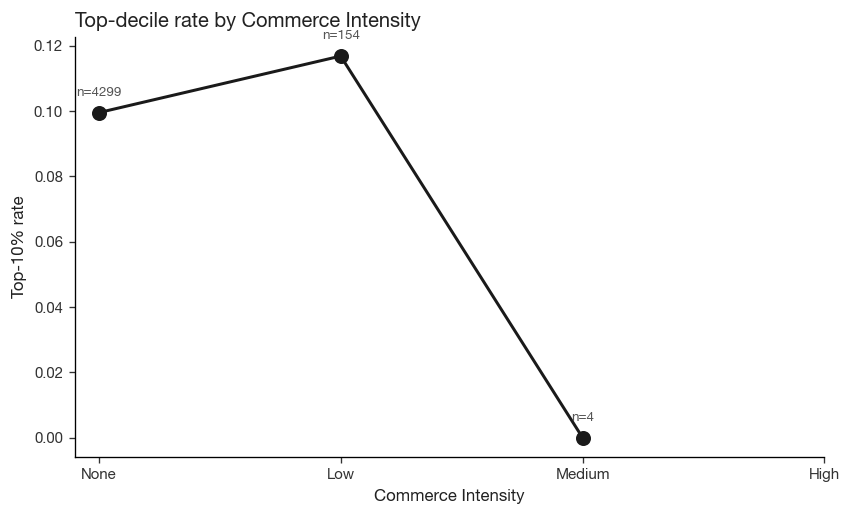

In [7]:
import matplotlib.pyplot as plt
trend = commerce_engagement_trend(df)
thr = trend.attrs.get("wer_threshold")
print(f"Top-10% = WER >= sample Q90 ({thr:.5f})")
display(
    trend.style.format(
        {
            "median_bri": "{:.3f}",
            "median_wer": "{:.4f}",
            "top10_rate": "{:.1%}",
        }
    )
)
fig = commerce_engagement_line(trend, y_col="median_bri", ylabel="Median BRI")
_show_fig(fig)
fig = commerce_engagement_line(
    trend,
    y_col="top10_rate",
    title="Top-decile rate by Commerce Intensity",
    ylabel="Top-10% rate",
)
_show_fig(fig)


## 5. Intensity × BRI matrix

Group bubbles: *x* = mean intensity, *y* = median BRI, size = *n*. Panel A: content; Panel B: product. Dashed lines at medians of plotted groups (descriptive quadrants).


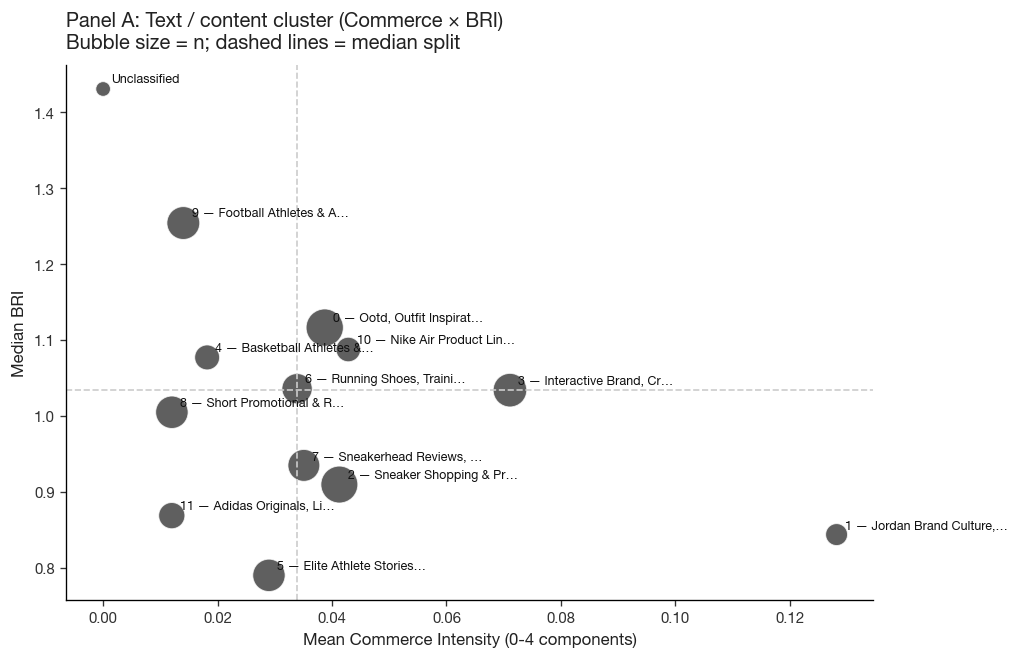

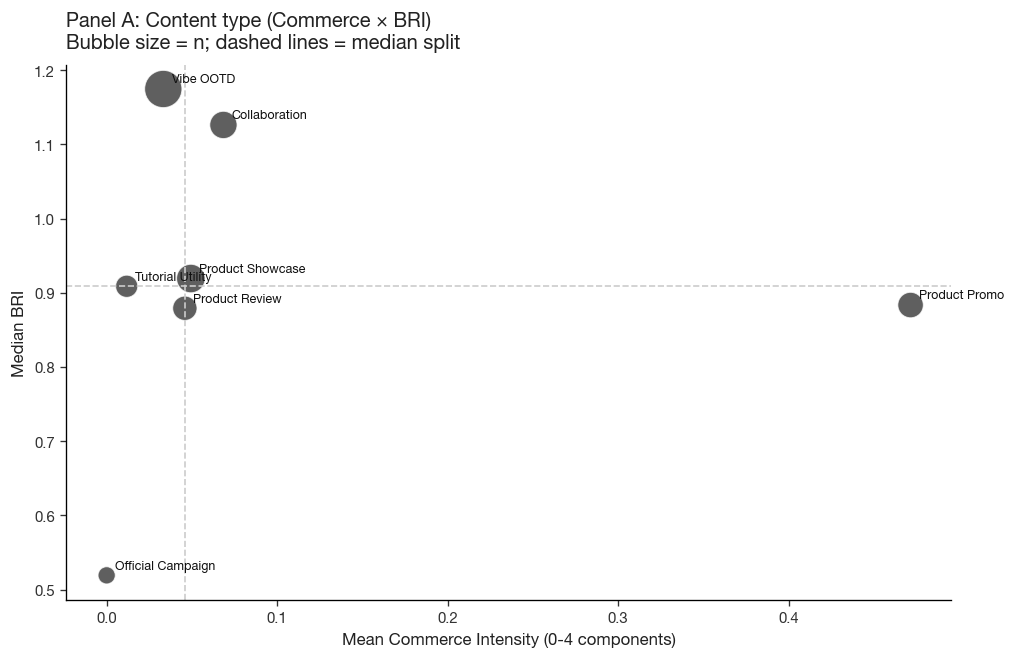

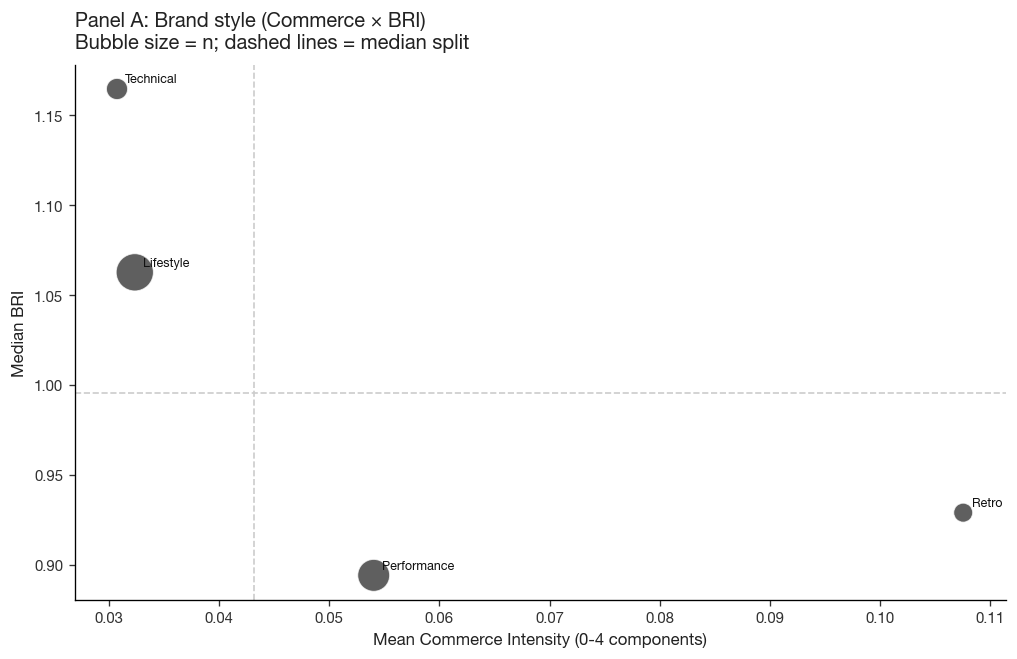

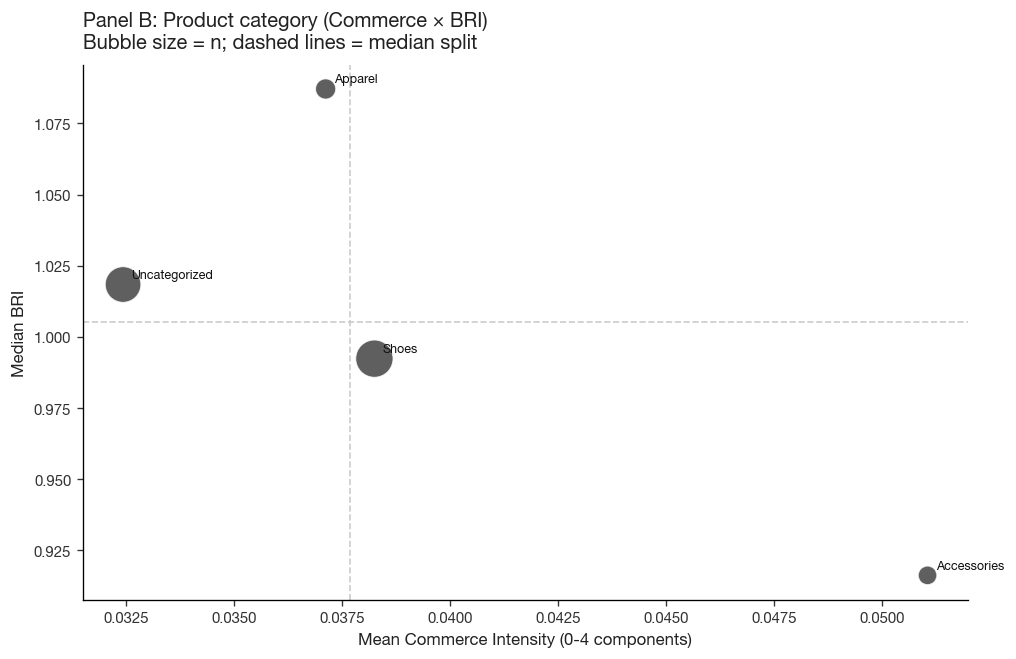

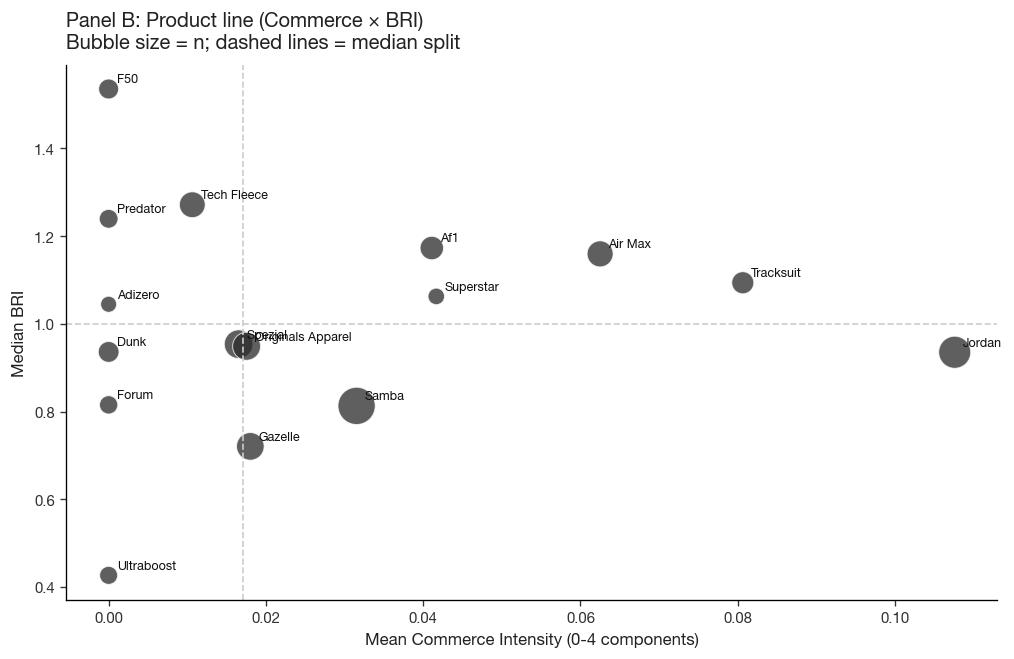

In [8]:
import matplotlib.pyplot as plt
panel_a = ["content_cluster", "content_type", "brand_styles"]
panel_b = ["product_categories", "product_lines"]

for dim in panel_a:
    if dim not in df.columns:
        continue
    bub = commerce_engagement_bubbles(df, dim, min_count=20)
    fig = commerce_bri_bubbles(
        bub,
        title=f"Panel A: {DIM_LABELS.get(dim, dim)} (Commerce × BRI)",
    )
    _show_fig(fig)

for dim in panel_b:
    if dim not in df.columns:
        continue
    bub = commerce_engagement_bubbles(df, dim, min_count=15)
    fig = commerce_bri_bubbles(
        bub,
        title=f"Panel B: {DIM_LABELS.get(dim, dim)} (Commerce × BRI)",
    )
    _show_fig(fig)


## 6. Summary

1. **Prevalence.** Of 4,457 videos: None 96.5%, Low 3.5%, Medium *n*=4, High 0. Component rates: purchase CTA 0.8%, discovery/traffic 0.9%, promo 1.8%, giveaway 0.1%.

2. **Where cues appear.** Highest mean intensity on `product_promo`; then collaboration / showcase / review. Official campaign ≈ 0. Product-line hotspots include Jordan, Air Max, AF1 (Nike) and selected Adidas lines (e.g. Tracksuit, Superstar, Samba).

3. **Brand gap.** Nike mean intensity 0.050 vs Adidas 0.022 (Low share 4.7% vs 2.1%). Gap is context-specific, not universal across all content.

4. **Engagement.** Median BRI: None 1.01 → Low 0.95 → Medium 0.87 (*n*=4). Insufficient for a dose-response or engagement-penalty claim. Top-10% rate is slightly higher for Low (11.7%) than None (10.0%).

5. **Matrix.** Higher-commerce / higher-BRI groups include collaboration and some OOTD-adjacent / product-line cells. Higher-commerce / lower-BRI groups include `product_promo`, product review, and several promo-heavy product cells. Descriptive only.

*Search-visible sample; rates are not platform-wide prevalence.*
